# 03A. Memisahkan Bilangan Pecahan
### Description
Pada saat mengurus pajak tahunan, Pak Algor selalu mendapatkan bilangan dalam bentuk pecahan, misalnya 54000.345124. Pada saat mengisi ke formulir yang disediakan oleh Kantor Pajak, Pak Algor harus memisahkan antara bagian bilangan bulat (54000) dan bagian bilangan pecahan (0.345124) ke dalam dua kotak terpisah. Bagian bilangan pecahan yang harus dituliskan selalu dalam lima digit, maka untuk contoh di atas, Pak Algor menuliskan angka 0.34512. Buatlah program untuk membantu Pak Algor menuliskan bagian bilangan bulat dan pecahan dari nilai pajak yang harus dibayarkan.

### Input Format
Data masukan berupa sebuah bilangan positif floating point.

### Output Format
Output program adalah dua bilangan yang dituliskan dalam satu baris yang dipisahkan oleh satu spasi, dimana bilangan sebelah kiri adalah sebuah bilangan bulat yang merupakan bagian bilangan bulat dari data masukan, dan sebelah kanan adalah bagian bilangan pecahan sesuai ketentuan di atas yang ditulis dalam 5 digit di belakang tanda desimal. Output ini diakhiri dengan newline.

### Sample Input
```
54000.945124
```
### Sample Output
```
54000 0.94512
```

In [23]:
%%writefile practicumWeek3a.c
# include <stdio.h>

int main() {
  double angkaAwal, angkaDesimal;
  int angkaBulat;
  
  scanf("%lf", &angkaAwal);
  
  angkaBulat = (int)angkaAwal;
  angkaDesimal = angkaAwal - (angkaBulat * 1.0);
  
  printf("%d %.5lf\n", angkaBulat, angkaDesimal);
}

Overwriting practicumWeek3a.c


In [24]:
!gcc practicumWeek3a.c -o practicumWeek3a && echo 54000.945124 | practicumWeek3a.exe

54000 0.94512


---
# 03B. Titik dan Lingkaran
### Description
Diketahui sebuah lingkaran dengan titik pusat berada di koordinat (0,0), dan ada beberapa koordinat titik yang tersebar. Buatlah program untuk menghitung berapa banyak titik yang berada di dalam lingkaran, dan berada di luar lingkaran.

### Input Format
Baris pertama adalah sebuah bilangan bulat yang menunjukkan jari-jari lingkaran. Beberapa baris berikutnya adalah koordinat tiitk x dan y yang masing-masing berupa bilangan bulat. Dan baris terakhir adalah nilai sentinel -999.

### Output Format
Dua bilangan yang dipisahkan oleh satu spasi, yang menunjukkan banyaknya titik di dalam lingkaran, dan banyaknya titik di luar lingkaran.

### Sample Input
```
5
0 0
1 2
3 4
5 6
-999
```
### Sample Output
```
2 1
```

### Penjelasan Teori (Segitiga Pythagoras)
Setiap titik koordinat $(x, y)$ membentuk sebuah **segitiga siku-siku** dengan titik pusat $(0,0)$.
* **Alas (x)**: Jarak horizontal dari pusat.
* **Tinggi (y)**: Jarak vertikal ke titik.
* **Sisi Miring (d)**: Jarak garis lurus dari pusat ke titik tersebut.

Berdasarkan Teorema Pythagoras, kuadrat jarak ($d^2$) adalah:  
$$d^2 = x^2 + y^2$$

Jika $d^2 < r^2$, titik ada di dalam. Jika $d^2 > r^2$, titik ada di luar. Jalankan kode Python di bawah ini untuk melihat visualisasi segitiganya secara langsung!

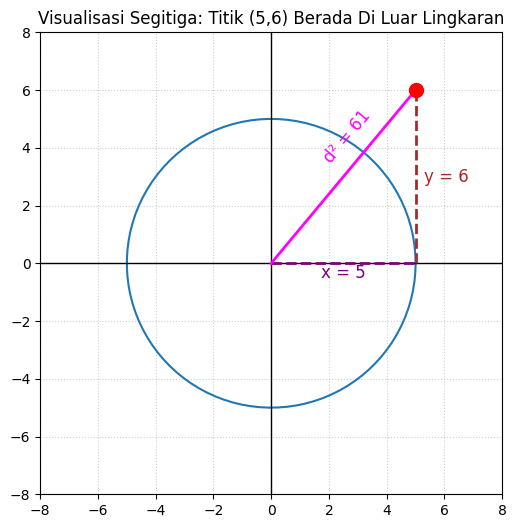

In [25]:
import matplotlib.pyplot as plt
import numpy as np

def plot_pythagoras_triangle(r, x, y):
    theta = np.linspace(0, 2*np.pi, 100)
    fig, ax = plt.subplots(figsize=(6, 6))
    
    # Gambar Lingkaran
    ax.plot(r*np.cos(theta), r*np.sin(theta), label=f'Lingkaran r={r}', color='#1f77b4')
    ax.axhline(0, color='black', lw=1)
    ax.axvline(0, color='black', lw=1)
    
    # Gambar Titik
    dist_sq = x**2 + y**2
    color = 'green' if dist_sq < r**2 else 'red' if dist_sq > r**2 else 'orange'
    ax.scatter(x, y, color=color, s=100, zorder=5)
    
    # GAMBAR SEGITIGA
    ax.plot([0, x], [0, 0], color='purple', linestyle='--', lw=2) # Alas (x)
    ax.plot([x, x], [0, y], color='brown', linestyle='--', lw=2)  # Tinggi (y)
    ax.plot([0, x], [0, y], color='magenta', linestyle='-', lw=2) # Sisi Miring (d)
    
    # Label Angka Segitiga
    ax.text(x/2, -0.5, f'x = {x}', color='purple', ha='center', fontsize=12)
    ax.text(x+0.3, y/2, f'y = {y}', color='brown', va='center', fontsize=12)
    ax.text(x/2 - 0.8, y/2 + 0.5, f'd\u00b2 = {dist_sq}', color='magenta', fontsize=12, rotation=np.degrees(np.arctan2(y, x)))
    
    # Konfigurasi Grafik
    status = "Di Dalam" if dist_sq < r**2 else "Di Luar" if dist_sq > r**2 else "Pada Garis"
    ax.set_title(f"Visualisasi Segitiga: Titik ({x},{y}) Berada {status} Lingkaran")
    ax.set_aspect('equal')
    ax.grid(True, linestyle=':', alpha=0.6)
    
    # Buat rentang sumbu dinamis agar gambar tidak terpotong
    max_val = max(r, abs(x), abs(y)) + 2
    ax.set_xlim(-max_val, max_val)
    ax.set_ylim(-max_val, max_val)
    plt.show()

# Tes visualisasi untuk titik (5, 6) dari sample input
plot_pythagoras_triangle(5, 5, 6)

In [26]:
%%writefile practicumWeek3b.c
# include <stdio.h>

int main() {
  int radius, x, y;
  int dalamLingkaran, luarLingkaran;
  double totalJarak;

  dalamLingkaran = 0;
  luarLingkaran = 0;

  scanf("%d", &radius);
  scanf("%d", &x);

  while (x != -999) {
    scanf("%d", &y);
    totalJarak = (x*x) + (y*y);

    if (totalJarak < (radius*radius)) {
      dalamLingkaran += 1;
    } else if (totalJarak > (radius*radius)) {
      luarLingkaran += 1;
    }
    scanf("%d", &x);
  }

  printf("%d %d\n", dalamLingkaran, luarLingkaran);
  return 0;
}

Overwriting practicumWeek3b.c


In [27]:
!gcc practicumWeek3b.c -o practicumWeek3b && echo 5 0 0 1 2 3 4 5 6 -999 | practicumWeek3b.exe

2 1


---
# 03C. Kertas dan Silinder
### Description
Dengan menggunakan kertas dan gunting, kita dapat memotong dua sisi untuk membentuk silinder dengan cara sebagai berikut:
1. Potong kertas secara horizontal (sejajar dengan sisi yang lebih pendek) untuk mendapatkan dua bagian persegi panjang.
2. Dari bagian pertama, potong kertas membentuk lingkaran dengan jari-jari paling maksimum. Lingkaran ini akan membentuk bagian bawah dari silinder.
3. Gulung bagian kedua sedemikian rupa sehingga memiliki keliling dengan panjang yang sama dengan keliling lingkaran, dan pasang salah satu ujung gulungan ke lingkaran. Perhatikan bahwa gulungan kertas mungkin memiliki beberapa bagian yang tumpang tindih untuk mendapatkan panjang perimeter yang diperlukan.

Diberikan dimensi selembar kertas, hitunglah volume silinder sebesar mungkin yang dapat dibangun menggunakan prosedur yang dijelaskan di atas. Buat programnya.

### Input Format
Data masukan terdiri atas beberapa kasus. Setiap kasus berisi 2 nilai lebar dan tinggi kertas (1 ≤ lebar ≤ tinggi ≤ 100). Data masukan diakhiri dengan nilai sentinel -1.

### Output Format
Untuk setiap kasus, tuliskan volume silinder paling besar yang mungkin bisa didapat. Catat dalam 3 digit di belakang tanda desimal, dan akhiri dengan newline. Asumsikan bahwa nilai PI untuk perhitungan volume silinder adalah 3.14159.

### Penjelasan Teori Skenario
**Skenario 1 (Tinggi silinder = Width kertas)**
* Keliling + Diameter menempati panjang kertas ($H$).
* $2\pi r + 2r = H \implies r = \frac{H}{2\pi + 2}$

**Skenario 2 (Tinggi silinder = Height kertas)**
* Keliling + Diameter menempati lebar kertas ($W$).
* $2\pi r + 2r = W \implies r = \frac{W}{2\pi + 2}$

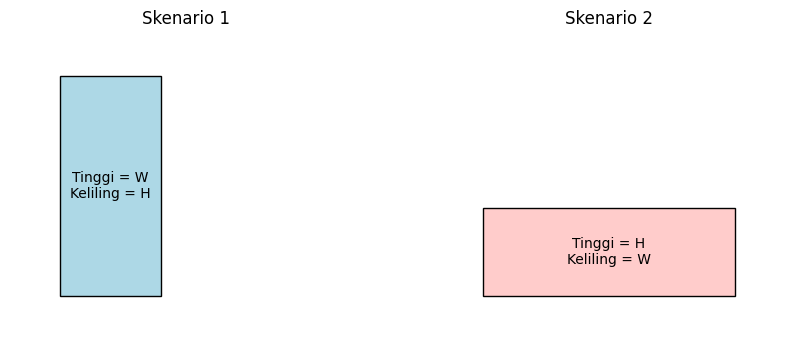

In [28]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def plot_cylinder_strategy():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    
    ax1.add_patch(patches.Rectangle((0,0), 2, 5, facecolor='#add8e6', edgecolor='black'))
    ax1.text(1, 2.5, 'Tinggi = W\nKeliling = H', ha='center', va='center')
    ax1.set_title("Skenario 1")
    ax1.set_xlim(-1, 6); ax1.set_ylim(-1, 6); ax1.axis('off')
    
    ax2.add_patch(patches.Rectangle((0,0), 5, 2, facecolor='#ffcccb', edgecolor='black'))
    ax2.text(2.5, 1, 'Tinggi = H\nKeliling = W', ha='center', va='center')
    ax2.set_title("Skenario 2")
    ax2.set_xlim(-1, 6); ax2.set_ylim(-1, 6); ax2.axis('off')
    
    plt.show()

plot_cylinder_strategy()

In [29]:
%%writefile practicumWeek3c.c
# include <stdio.h>

int main() {
  double pi = 3.14159;
  double width, height, radius;
  double volume1, volume2;

  while (1) {
    scanf("%lf", &width);
    if (width == -1) break;
    scanf("%lf", &height);

    // Skenario 1
    radius = height/(2*pi + 2);
    if (radius > width/2.0) {
      radius = width/2.0;
    }
    volume1 = pi*(radius*radius)*width;

    // Skenario 2
    radius = width/(2*pi + 2);
    if (radius > height/2.0) {
      radius = height/2.0;
    }
    volume2 = pi*(radius*radius)*height;

    if (volume1 >= volume2) {
      printf("%.3lf\n", volume1);
    } else {
      printf("%.3lf\n", volume2);
    }
  }
  return 0;
}

Overwriting practicumWeek3c.c


In [30]:
!gcc practicumWeek3c.c -o practicumWeek3c && echo 10 10 10 50 10 30 -1 | practicumWeek3c.exe

45.788
785.398
412.095
